# Feature Importance & Sélection de variables

Ce notebook est un **guide d'explicabilité** des modèles de Machine Learning, à la fois **tutoriel** (le quoi/pourquoi/quand de chaque méthode), **wiki technique** (les maths : impureté, Shapley, information mutuelle, régularisation L1/L2) et **cheat-sheet** (fonctions typées réutilisables).

Deux fils rouges traversent tout le document :

1. **Trianguler plusieurs méthodes.** Aucune mesure d'importance n'est neutre : chacune a ses biais. La confiance vient de leur **convergence**, pas d'un chiffre isolé.
2. **Importance ≠ causalité.** Une variable importante *pour la prédiction* n'est pas forcément une *cause* du phénomène.

Pour rendre les biais **observables**, on travaille sur un jeu unique — **California Housing** (régression : prix médian des logements) — auquel on ajoute deux variables « pièges » dont on connaît la vérité terrain :

- `noise_random` : bruit pur, sans aucun lien avec la cible → toute méthode correcte doit lui donner une importance **nulle**.
- `MedInc_copy` : quasi-copie de `MedInc` → illustre comment les méthodes gèrent la **redondance**.

> Le notebook couvre : importance par modèle (MDI), permutation, drop-column, information mutuelle, coefficients linéaires, **SHAP** (global, local, dépendance, interactions, redondance, **classification binaire & multiclasse**, **variables catégorielles**, **deep learning**), **LIME**, la **sélection de variables** (filter / wrapper / embedded / Boruta), une **synthèse comparative**, et une **annexe « galerie de visualisation scikit-learn »** (courbes ROC/PR/calibration, matrices de confusion, courbes d'apprentissage…).

## 0. Configuration et helpers

On fixe une graine globale pour la reproductibilité et on définit la **palette de couleurs** du projet. Convention de couleurs pour ce notebook : une importance est une grandeur univariée → on la trace en une seule couleur (`PRIMARY_1`), et on met en évidence une variable d'intérêt (souvent une variable piège) en rouge (`MAUVAIS`).

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

# Palette CHART du projet
PRIMARY_1 = "#00798c"
MAUVAIS = "#d1495b"
MOYEN = "#edae49"
ACCENT = "#66a182"
ACCENT_DARK = "#2e4057"
LAVENDER = "#9d83b8"
DUSTY_ROSE = "#b8848e"
BEIGE = "#c9b78b"
PALETTE = [PRIMARY_1, MAUVAIS, MOYEN, ACCENT, ACCENT_DARK, LAVENDER, DUSTY_ROSE, BEIGE]

plt.rcParams.update({"figure.dpi": 90, "figure.autolayout": True})

Un helper réutilisable pour tracer un classement d'importances. Il trie, colore uniformément, et met optionnellement en avant une ou plusieurs variables.

In [ ]:
def plot_importance_bar(
    scores: pd.Series,
    title: str,
    highlight: str | list[str] | None = None,
    ax: plt.Axes | None = None,
) -> plt.Axes:
    """Trace un barplot horizontal d'importances triées.

    Args:
        scores: index = noms de features, valeurs = importances.
        title: titre du graphique.
        highlight: feature(s) à mettre en avant (couleur MAUVAIS).
        ax: axe matplotlib optionnel.
    Returns:
        L'axe utilisé.
    """
    if ax is None:
        _, ax = plt.subplots(figsize=(7, 4))
    s = scores.sort_values()
    hl = {highlight} if isinstance(highlight, str) else set(highlight or [])
    colors = [MAUVAIS if name in hl else PRIMARY_1 for name in s.index]
    ax.barh(s.index, s.values, color=colors)
    ax.set_title(title)
    ax.set_xlabel("importance")
    return ax

## 1. Données : California Housing + variables pièges

California Housing décrit ~20 600 quartiers californiens par 8 variables (revenu médian `MedInc`, âge des logements, nombre moyen de pièces, position géographique, etc.). La cible est le **prix médian** (en centaines de milliers de dollars).

On enrichit la matrice avec deux variables de contrôle, dont on **connaît la réponse attendue** :

- `noise_random` ~ N(0, 1) : bruit pur, haute cardinalité. Le **MDI** (section 2) va lui attribuer une importance non nulle — c'est précisément le biais qu'on veut démasquer.
- `MedInc_copy` = `MedInc` + bruit infime : corrélation ≈ 1 avec `MedInc`. Sert à observer comment chaque méthode répartit l'importance entre deux variables redondantes.

In [ ]:
from sklearn.datasets import fetch_california_housing


def load_data(seed: int = RANDOM_STATE) -> tuple[pd.DataFrame, pd.Series]:
    """Charge California Housing et ajoute 2 features de contrôle.

    - noise_random : bruit pur N(0,1), haute cardinalité (piège pour le MDI).
    - MedInc_copy  : MedInc + petit bruit -> fortement corrélée (piège permutation).
    Returns:
        (X enrichi, y cible = prix médian en 100k$).
    """
    bunch = fetch_california_housing(as_frame=True)
    X = bunch.data.copy()
    y = bunch.target.copy()
    local_rng = np.random.default_rng(seed)
    X["noise_random"] = local_rng.standard_normal(len(X))
    X["MedInc_copy"] = X["MedInc"] + local_rng.normal(0, 0.01, len(X))
    return X, y


X, y = load_data()
print("X shape:", X.shape, "| features:", list(X.columns))

On réserve un jeu de test : toutes les méthodes *agnostiques* (permutation, drop-column) seront évaluées dessus, pour mesurer une importance qui reflète la **généralisation** et non l'ajustement au train.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE
)
print("train:", X_train.shape, "test:", X_test.shape)
print(X.head(3))

## 2. Importance par modèle (model-specific)

Avant de mesurer l'importance, regardons la **structure de corrélation**. C'est la clé pour interpréter tout ce qui suit : `MedInc` et `MedInc_copy` sont quasi identiques (corrélation ≈ 1). On utilise une heatmap avec une carte de couleurs **divergente** centrée sur 0 (`RdBu_r`), adaptée aux corrélations signées.

In [ ]:
corr = X.corr(method="pearson")
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax, cbar_kws={"shrink": .8})
ax.set_title("Corrélation des features (MedInc ↔ MedInc_copy ≈ 1)")
print("corr MedInc/MedInc_copy:", round(corr.loc["MedInc", "MedInc_copy"], 4))

La forte corrélation `MedInc` / `MedInc_copy` aura des conséquences visibles : le MDI et la permutation vont se « partager » ou se « masquer » l'importance entre les deux.

### 2.1 MDI — importance par impureté

Le **MDI** (*Mean Decrease in Impurity*) est l'importance « native » des modèles à base d'arbres (`feature_importances_`). À chaque split sur une variable $j$, l'arbre réduit l'impureté (variance pour la régression) ; le MDI somme ces réductions, pondérées par la fraction d'échantillons concernés, puis fait la moyenne sur tous les arbres :

$$\text{MDI}(j) = \frac{1}{N_{\text{arbres}}} \sum_{\text{arbres}} \ \sum_{\substack{n \in \text{splits sur } j}} \frac{N_n}{N} \,\Delta i(n)$$

où $\Delta i(n)$ est la baisse d'impureté au nœud $n$ et $N_n/N$ la proportion d'échantillons qui le traversent. C'est rapide (calculé pendant l'entraînement) mais **biaisé** (voir 2.2).

In [ ]:
from sklearn.ensemble import RandomForestRegressor


def train_tree_model(X_tr: pd.DataFrame, y_tr: pd.Series) -> RandomForestRegressor:
    """Entraîne une RandomForest de régression (modèle de référence pour le MDI)."""
    model = RandomForestRegressor(
        n_estimators=200, max_depth=12, n_jobs=-1, random_state=RANDOM_STATE
    )
    model.fit(X_tr, y_tr)
    return model


def mdi_importance(model: RandomForestRegressor, feature_names: list[str]) -> pd.Series:
    """Importance par impureté (Mean Decrease in Impurity)."""
    return pd.Series(model.feature_importances_, index=feature_names, name="MDI")


rf = train_tree_model(X_train, y_train)
mdi = mdi_importance(rf, list(X.columns))
print(mdi.sort_values(ascending=False).round(4))

Visualisation du classement MDI.

In [ ]:
plot_importance_bar(mdi, "MDI — importance par impureté (RandomForest)")

Deux mises en garde sur le MDI : il est calculé **sur le train** (il ne dit rien sur la généralisation), et il est **biaisé en faveur des variables à forte cardinalité** (nombreuses valeurs distinctes → plus d'opportunités de split). La section suivante le démontre.

### 2.2 Démonstration du biais de cardinalité

`noise_random` est du bruit pur : sa vraie importance est **zéro**. Pourtant le MDI lui attribue une valeur non négligeable, simplement parce que sa haute cardinalité offre beaucoup de seuils de split exploitables par hasard. On le met en évidence en rouge.

In [ ]:
plot_importance_bar(
    mdi, "Biais du MDI : noise_random reçoit une importance non nulle", highlight="noise_random"
)
print("MDI(noise_random) =", round(float(mdi["noise_random"]), 4), "(vérité = 0)")

Conclusion : ne jamais conclure sur le seul MDI. Il faut une méthode évaluée **hors échantillon** → la permutation.

## 3. Permutation importance (model-agnostic)

La **permutation importance** est *agnostique au modèle* : on mesure de combien le score chute quand on **mélange aléatoirement** une colonne (ce qui détruit son lien avec la cible) sans réentraîner. Calculée sur le **test** :

$$\text{Imp}(j) = s_{\text{ref}} - \frac{1}{K}\sum_{k=1}^{K} s\big(\text{modèle},\ X_{\text{test}}^{(\pi_k^{(j)})},\ y_{\text{test}}\big)$$

où $s$ est le score (R² ici), $\pi_k^{(j)}$ une permutation de la colonne $j$, et $K$ le nombre de répétitions (pour estimer la variance). Une variable inutile donne une importance ≈ 0.

In [ ]:
from sklearn.inspection import permutation_importance


def permutation_importance_df(
    model, X_eval: pd.DataFrame, y_eval: pd.Series, n_repeats: int = 10
) -> pd.DataFrame:
    """Permutation importance sur held-out -> DataFrame (mean, std, + valeurs brutes)."""
    res = permutation_importance(
        model, X_eval, y_eval, n_repeats=n_repeats, random_state=RANDOM_STATE, n_jobs=-1
    )
    df = pd.DataFrame(
        {"mean": res.importances_mean, "std": res.importances_std}, index=X_eval.columns
    ).sort_values("mean", ascending=False)
    df.attrs["raw"] = pd.DataFrame(res.importances.T, columns=X_eval.columns)
    return df


perm = permutation_importance_df(rf, X_test, y_test, n_repeats=10)
print(perm.round(4))

Visualisation du classement par permutation.

In [ ]:
plot_importance_bar(perm["mean"], "Permutation importance (sur le test)")

La répétition (`n_repeats`) donne une **distribution** par variable, pas un point unique : un boxplot rend la variance lisible. (Note : on passe `tick_labels=` — l'argument `labels=` de `boxplot` est déprécié depuis matplotlib 3.9.)

In [ ]:
raw = perm.attrs["raw"]
order = perm.index.tolist()[::-1]
fig, ax = plt.subplots(figsize=(7, 5))
ax.boxplot([raw[c] for c in order], vert=False, tick_labels=order)
ax.set_title("Distribution des importances par permutation (n_repeats=10)")
ax.set_xlabel("chute de R²")

**Caveat des variables corrélées.** La permutation **sous-estime** les variables redondantes : quand on mélange `MedInc`, le modèle récupère presque la même information via `MedInc_copy`, donc la chute de score est faible — et inversement. Aucune des deux ne paraît cruciale, alors que l'information qu'elles portent l'est. On y revient en 7.5 (clustering de redondance).

## 4. Drop-column importance

La méthode conceptuellement la plus exacte : pour chaque variable, on **réentraîne** le modèle sans elle et on mesure la perte de performance.

$$\text{Imp}(j) = s_{\text{ref}} - s_{\text{modèle réentraîné sans } j}$$

Contrairement à la permutation (qui garde le même modèle), on laisse le modèle se réorganiser. C'est plus fidèle mais **coûteux** : $O(p)$ réentraînements pour $p$ variables.

In [ ]:
from sklearn.base import clone
from sklearn.metrics import r2_score


def drop_column_importance(
    model, X_tr: pd.DataFrame, y_tr: pd.Series, X_te: pd.DataFrame, y_te: pd.Series
) -> pd.Series:
    """Importance par retrait de colonne : baisse de R² test après refit sans la feature."""
    base = clone(model).fit(X_tr, y_tr)
    base_score = r2_score(y_te, base.predict(X_te))
    scores: dict[str, float] = {}
    for col in X_tr.columns:
        m = clone(model).fit(X_tr.drop(columns=col), y_tr)
        scores[col] = base_score - r2_score(y_te, m.predict(X_te.drop(columns=col)))
    return pd.Series(scores, name="drop_column").sort_values(ascending=False)


# modèle plus léger : on réentraîne autant de fois qu'il y a de colonnes
rf_light = RandomForestRegressor(n_estimators=80, max_depth=12, n_jobs=-1, random_state=RANDOM_STATE)
dropcol = drop_column_importance(rf_light, X_train, y_train, X_test, y_test)
print(dropcol.round(4))

Visualisation du classement drop-column.

In [ ]:
plot_importance_bar(dropcol, "Drop-column importance (baisse de R²)")

Même symptôme que la permutation sur les corrélées : retirer `MedInc` *ou* `MedInc_copy` ne coûte presque rien (l'autre prend le relais), donc chacune apparaît peu importante prise isolément.

## 5. Mutual information (model-free)

L'**information mutuelle** mesure la dépendance statistique entre une variable et la cible, **sans modèle** :

$$I(X_j; Y) = \iint p(x_j, y)\,\log\frac{p(x_j, y)}{p(x_j)\,p(y)}\,dx_j\,dy \ \ge 0$$

$I = 0$ ⟺ indépendance. Contrairement à la corrélation de Pearson, elle capte les relations **non linéaires**. `mutual_info_regression` l'estime par une méthode k-plus-proches-voisins. Utile comme **filtre** rapide, model-free.

In [ ]:
from sklearn.feature_selection import mutual_info_regression

mi_vals = mutual_info_regression(X, y, random_state=RANDOM_STATE)
mi = pd.Series(mi_vals, index=X.columns, name="mutual_info").sort_values(ascending=False)
print(mi.round(4))
plot_importance_bar(mi, "Mutual information (model-free)", highlight="noise_random")

`noise_random` tombe à ~0 (bon comportement, contrairement au MDI). Limite : l'information mutuelle est *univariée* — elle ignore les interactions entre variables qu'un modèle, lui, exploiterait.

## 6. Coefficients de modèles linéaires

Pour un modèle linéaire $\hat{y} = \beta_0 + \sum_j \beta_j x_j$, l'importance d'une variable est liée à $|\beta_j|$ — **mais uniquement si les variables sont à la même échelle**. Sans standardisation, un coefficient peut être grand simplement parce que la variable est en petites unités. On standardise donc (moyenne 0, écart-type 1) avant de comparer.

On compare trois régressions : **OLS** (sans pénalité), **Ridge** (pénalité L2, $\lambda\sum\beta_j^2$) et **Lasso** (pénalité L1, $\lambda\sum|\beta_j|$).

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

linear_models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0, random_state=RANDOM_STATE),
    "Lasso": Lasso(alpha=0.1, random_state=RANDOM_STATE),
}
coef_table = {}
for name, est in linear_models.items():
    pipe = make_pipeline(StandardScaler(), est)
    pipe.fit(X_train, y_train)
    coef_table[name] = pd.Series(pipe[-1].coef_, index=X.columns)
coefs = pd.DataFrame(coef_table)
print(coefs.round(3))

Comparaison des amplitudes de coefficients entre les trois régressions.

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
coefs.abs().plot.barh(ax=ax, color=PALETTE[:3])
ax.set_title("|Coefficients| standardisés — Linear vs Ridge vs Lasso")
ax.set_xlabel("|coefficient|")

**Géométrie L1 vs L2.** Le Lasso met certains coefficients **exactement à zéro** : il fait donc de la sélection de variables. La raison est géométrique — la contrainte L1 forme un losange à coins pointus (sur les axes), et la solution touche souvent un coin → un coefficient nul. La contrainte L2 (un cercle) rétrécit les coefficients sans les annuler. Le **chemin de régularisation** le montre : à mesure que `alpha` augmente, les coefficients Lasso s'éteignent un à un.

In [ ]:
from sklearn.linear_model import lasso_path

Xs = StandardScaler().fit_transform(X_train)
alphas, coefs_path, _ = lasso_path(Xs, y_train, n_alphas=50)
fig, ax = plt.subplots(figsize=(8, 5))
for i, col in enumerate(X.columns):
    ax.plot(alphas, coefs_path[i], color=PALETTE[i % len(PALETTE)], label=col)
ax.set_xscale("log")
ax.invert_xaxis()
ax.set_xlabel("alpha (log)")
ax.set_ylabel("coefficient")
ax.set_title("Chemin de régularisation Lasso — la sparsité fait la sélection")
ax.legend(fontsize=7, ncol=2)

## 7. SHAP — valeurs de Shapley

Les **valeurs de Shapley** viennent de la théorie des jeux coopératifs : elles répartissent « équitablement » la prédiction entre les variables. La valeur SHAP d'une variable $j$ pour une observation est sa **contribution marginale moyenne**, sur tous les ordres d'ajout possibles des variables :

$$\phi_j = \sum_{S \subseteq F \setminus \{j\}} \frac{|S|!\,(|F|-|S|-1)!}{|F|!}\Big[f\big(S \cup \{j\}\big) - f(S)\Big]$$

Propriétés clés : **additivité** ($f(x) = \mathbb{E}[f] + \sum_j \phi_j$, la somme des contributions reconstitue la prédiction), **symétrie**, et **variable nulle** (contribution nulle si la variable n'influe pas).

API moderne : on construit un `shap.Explainer(model)` puis on l'appelle sur les données pour obtenir un objet `Explanation` (qui porte valeurs, base, données et noms). Les anciennes fonctions `summary_plot` / `force_plot` sont *legacy* — on utilise `shap.plots.*`.

### 7.1 SHAP global

On entraîne un modèle de boosting (XGBoost), bien adapté au `TreeExplainer` exact et rapide de SHAP, puis on calcule l'`Explanation` sur un sous-échantillon du test (pour des graphiques lisibles).

In [ ]:
import shap
import xgboost as xgb


def shap_explanation(model, X_bg: pd.DataFrame) -> "shap.Explanation":
    """Calcule l'objet Explanation (API moderne) pour un modèle d'arbres."""
    explainer = shap.Explainer(model)
    return explainer(X_bg)


xgb_model = xgb.XGBRegressor(
    n_estimators=300, max_depth=4, learning_rate=0.05, n_jobs=-1, random_state=RANDOM_STATE
)
xgb_model.fit(X_train, y_train)

# sous-échantillon test pour des plots SHAP rapides et lisibles
X_shap = X_test.sample(n=min(2000, len(X_test)), random_state=RANDOM_STATE)
sv = shap_explanation(xgb_model, X_shap)
print("SHAP values shape:", sv.shape)

L'importance globale = moyenne des valeurs absolues SHAP par variable. Le **bar plot** donne le classement.

In [ ]:
shap.plots.bar(sv)

Le **beeswarm** est plus riche : chaque point est une observation, l'axe horizontal est la valeur SHAP (effet sur la prédiction) et la **couleur** est la valeur de la variable. On voit donc non seulement l'importance mais le **sens** de l'effet (ex : un `MedInc` élevé pousse le prix vers le haut).

In [ ]:
shap.plots.beeswarm(sv)

### 7.2 SHAP local

SHAP explique aussi une **prédiction individuelle**. Le **waterfall** part de la valeur de base $\mathbb{E}[f(x)]$ et empile les contributions de chaque variable jusqu'à la prédiction finale $f(x)$. On utilise `waterfall` (statique, exportable) plutôt que l'ancien `force_plot` (JavaScript, non exporté en notebook statique).

In [ ]:
shap.plots.waterfall(sv[0])

Une autre observation, pour comparer deux profils de contributions.

In [ ]:
shap.plots.waterfall(sv[1])

### 7.3 SHAP — graphiques de dépendance

Le **scatter plot** montre comment l'effet (valeur SHAP) d'une variable évolue avec sa valeur. La dispersion verticale à une même valeur révèle des **interactions** ; SHAP colore automatiquement par la variable qui interagit le plus.

In [ ]:
shap.plots.scatter(sv[:, "MedInc"], color=sv[:, "AveOccup"])

Un second graphique de dépendance sur une autre variable.

In [ ]:
shap.plots.scatter(sv[:, "HouseAge"], color=sv[:, "MedInc"])

### 7.4 SHAP — valeurs d'interaction

Les **valeurs d'interaction SHAP** décomposent chaque contribution en effets **principaux** (diagonale) et effets d'**interaction par paires** (hors-diagonale). Le calcul est ~quadratique en nombre de variables → on le fait sur un petit sous-échantillon. La heatmap des interactions moyennes (en valeur absolue) montre quelles paires interagissent.

In [ ]:
X_inter = X_test.sample(n=min(400, len(X_test)), random_state=RANDOM_STATE)
tree_expl = shap.TreeExplainer(xgb_model)
inter_vals = tree_expl.shap_interaction_values(X_inter)
print("interaction values shape:", np.asarray(inter_vals).shape)

Heatmap des interactions moyennes (cmap divergente, pas la palette CHART).

In [ ]:
inter_abs = np.abs(inter_vals).mean(axis=0)
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(
    inter_abs, xticklabels=X.columns, yticklabels=X.columns, cmap="RdBu_r", center=0, ax=ax
)
ax.set_title("Interactions SHAP moyennes (|valeur|)")

### 7.5 SHAP et redondance — clustering hiérarchique

On a vu que permutation et drop-column sous-estiment les variables corrélées. SHAP propose une mesure de **redondance** plus fiable que la corrélation : `shap.utils.hclust` entraîne de petits modèles pour regrouper les variables qui portent la même information. Passé au bar plot, ce clustering affiche la structure de redondance **en même temps** que l'importance — `MedInc` et `MedInc_copy` devraient former un groupe.

In [ ]:
# hclust entraîne C(p,2) petits modèles : on sous-échantillonne pour rester rapide
X_hc = X_shap.iloc[:300]
clustering = shap.utils.hclust(X_hc, y_test.loc[X_hc.index])
shap.plots.bar(sv, clustering=clustering, clustering_cutoff=0.5)

Les **cohortes** segmentent la population en sous-groupes (ici 2, trouvés automatiquement) et comparent leurs importances moyennes : utile pour détecter une hétérogénéité (l'importance d'une variable peut différer selon le sous-groupe).

In [ ]:
shap.plots.bar(sv.cohorts(2).abs.mean(0))

### 7.6 SHAP en classification (binaire et multiclasse)

Jusqu'ici SHAP servait sur une **régression**. En **classification**, l'objet `Explanation` gagne un axe « classe » : sa forme devient `(n_observations, n_features, n_classes)`. On explique alors les contributions **vers une classe donnée**.

Premier cas : **classification binaire** sur Titanic (survie). On indexe la classe positive (`survived = 1`) via `sv[:, :, 1]`.

In [ ]:
from sklearn.ensemble import RandomForestClassifier


def prepare_titanic() -> tuple[pd.DataFrame, pd.Series]:
    """Titanic depuis seaborn -> features numériques simples + cible survived."""
    df = sns.load_dataset("titanic")
    cols = ["pclass", "sex", "age", "sibsp", "parch", "fare"]
    d = df[cols + ["survived"]].copy()
    d["sex"] = (d["sex"] == "male").astype(int)
    d["age"] = d["age"].fillna(d["age"].median())
    d["fare"] = d["fare"].fillna(d["fare"].median())
    return d[cols], d["survived"]


Xt, yt = prepare_titanic()
Xt_tr, Xt_te, yt_tr, yt_te = train_test_split(
    Xt, yt, test_size=0.3, random_state=RANDOM_STATE, stratify=yt
)
rf_clf = RandomForestClassifier(n_estimators=300, max_depth=5, random_state=RANDOM_STATE, n_jobs=-1)
rf_clf.fit(Xt_tr, yt_tr)
print("Titanic accuracy:", round(rf_clf.score(Xt_te, yt_te), 3))

expl_t = shap.TreeExplainer(rf_clf)
sv_t = expl_t(Xt_te)
print("Titanic SHAP shape:", sv_t.shape)  # (n, features, 2)

On trace l'importance et le sens des effets **pour la classe « survie »** : bar (importance globale), beeswarm (importance + sens), waterfall (une prédiction individuelle).

In [ ]:
sv_t_pos = sv_t[:, :, 1]  # contributions vers la classe positive (survived=1)
shap.plots.bar(sv_t_pos)

Le beeswarm révèle le sens : par exemple `sex` (= homme) pousse fortement vers la non-survie.

In [ ]:
shap.plots.beeswarm(sv_t_pos)

Et l'explication locale d'un passager donné (waterfall).

In [ ]:
shap.plots.waterfall(sv_t_pos[0])

Second cas : **classification multiclasse** sur Iris (3 espèces). L'`Explanation` a alors une 3ᵉ dimension de taille 3. On peut **agréger** l'importance sur toutes les classes (moyenne des |SHAP|) ou **détailler par classe** (un beeswarm par espèce).

In [ ]:
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
Xi, yi = iris.data, iris.target
Xi_tr, Xi_te, yi_tr, yi_te = train_test_split(
    Xi, yi, test_size=0.3, random_state=RANDOM_STATE, stratify=yi
)
rf_iris = RandomForestClassifier(n_estimators=200, max_depth=4, random_state=RANDOM_STATE)
rf_iris.fit(Xi_tr, yi_tr)
expl_i = shap.TreeExplainer(rf_iris)
sv_i = expl_i(Xi_te)
print("Iris SHAP shape:", sv_i.shape)  # (n, features, 3)

Importance globale agrégée sur les 3 classes (moyenne des valeurs absolues).

In [ ]:
imp_iris = pd.Series(
    np.abs(sv_i.values).mean(axis=(0, 2)), index=Xi.columns, name="|SHAP| Iris"
)
plot_importance_bar(imp_iris, "Iris — importance globale |SHAP| (3 classes agrégées)")

Détail **par classe** : on indexe la dernière dimension `sv_i[:, :, k]`. Ci-dessous, le beeswarm pour chaque espèce — on voit que la longueur/largeur des pétales discrimine surtout *virginica* et *versicolor*.

In [ ]:
for k, cls in enumerate(iris.target_names):
    print("beeswarm classe:", cls)
    shap.plots.beeswarm(sv_i[:, :, k])

### 7.7 SHAP avec des variables catégorielles

Les variables **catégorielles** demandent un traitement particulier. Deux stratégies :

1. **Modèle nativement catégoriel** (CatBoost, LightGBM) : pas d'encodage, une valeur SHAP par variable d'origine — interprétation directe.
2. **One-hot + modèle d'arbres** : chaque modalité devient une colonne binaire ; il faut ensuite **regrouper** les valeurs SHAP des modalités d'une même variable pour retrouver son importance globale.

CatBoost encode les catégories par *target/ordered encoding* (illustration ci-dessous), ce qui évite l'explosion dimensionnelle du one-hot tout en restant non biaisé.

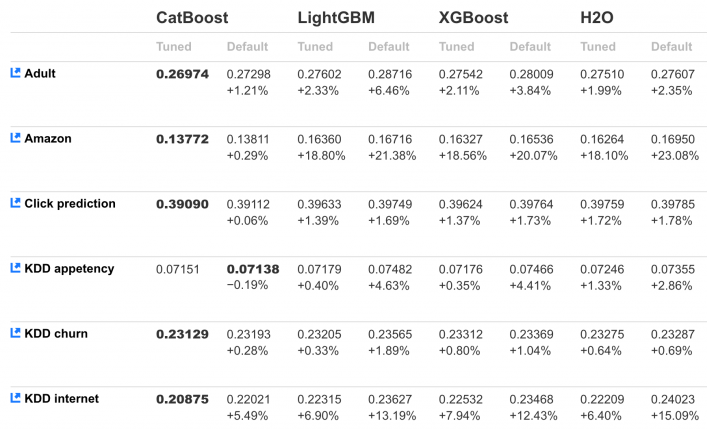

On illustre sur les variables **qualitatives de Titanic** (`sex`, `class`, `embarked`, `who`, `alone`). *(Le jeu « mushrooms » d'OpenML est l'exemple historique équivalent.)*

In [ ]:
df_cat = sns.load_dataset("titanic")
cat_cols = ["sex", "class", "embarked", "who", "alone"]
dca = df_cat[cat_cols + ["survived"]].dropna().copy()
for c in cat_cols:
    dca[c] = dca[c].astype(str)
Xm = dca[cat_cols]
ym = dca["survived"].astype(int)
Xm_tr, Xm_te, ym_tr, ym_te = train_test_split(
    Xm, ym, test_size=0.3, random_state=RANDOM_STATE, stratify=ym
)
print("Catégoriel X:", Xm.shape, "| cats:", cat_cols)

**(a) CatBoost natif.** On déclare les colonnes catégorielles via `cat_features` dans un `Pool`. Les valeurs SHAP s'obtiennent directement par `get_feature_importance(..., type="ShapValues")` (la dernière colonne est la valeur de base $\mathbb{E}[f]$). On reconstruit un objet `Explanation` pour réutiliser `shap.plots`.

In [ ]:
from catboost import CatBoostClassifier, Pool

cat_idx = list(range(Xm.shape[1]))
pool_tr = Pool(Xm_tr, ym_tr, cat_features=cat_idx)
pool_te = Pool(Xm_te, ym_te, cat_features=cat_idx)
cb = CatBoostClassifier(iterations=150, depth=6, learning_rate=0.1,
                        random_state=RANDOM_STATE, verbose=0)
cb.fit(pool_tr)
print("CatBoost accuracy:", round(cb.score(Xm_te, ym_te), 3))

raw_sv = cb.get_feature_importance(pool_te, type="ShapValues")  # (n, F+1)
expected_value = float(raw_sv[0, -1])
sv_cat = raw_sv[:, :-1]
expl_cat = shap.Explanation(
    values=sv_cat,
    base_values=np.full(len(Xm_te), expected_value),
    data=Xm_te.reset_index(drop=True),
    feature_names=cat_cols,
)

Importance globale (bar) et explication locale (waterfall) — une valeur par variable catégorielle.

In [ ]:
shap.plots.bar(expl_cat)

In [ ]:
shap.plots.waterfall(expl_cat[0])

**(b) One-hot + regroupement.** Avec un encodage one-hot, chaque **modalité** a sa propre valeur SHAP. Pour retrouver l'importance d'une **variable**, on **somme les |SHAP| de ses modalités**. C'est l'étape clef quand on n'a pas de modèle nativement catégoriel.

In [ ]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
Xoh_tr = ohe.fit_transform(Xm_tr)
Xoh_te = ohe.transform(Xm_te)
oh_names = ohe.get_feature_names_out(cat_cols)
rf_oh = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=RANDOM_STATE, n_jobs=-1)
rf_oh.fit(Xoh_tr, ym_tr)
expl_oh = shap.TreeExplainer(rf_oh)
sv_oh = expl_oh.shap_values(Xoh_te)

# classe positive puis regroupement des modalités par variable d'origine
sv_oh_pos = np.asarray(sv_oh[..., 1] if np.asarray(sv_oh).ndim == 3 else sv_oh)
grouped: dict[str, float] = {}
for j, name in enumerate(oh_names):
    origin = next((c for c in cat_cols if name.startswith(c + "_")), name)
    grouped[origin] = grouped.get(origin, 0.0) + np.abs(sv_oh_pos[:, j]).mean()
grouped_imp = pd.Series(grouped, name="|SHAP| regroupé").sort_values(ascending=False)
print(grouped_imp.round(3))

Le classement regroupé (one-hot sommé) retrouve les mêmes variables dominantes que CatBoost natif.

In [ ]:
plot_importance_bar(grouped_imp, "SHAP regroupé par variable catégorielle (one-hot sommé)")

### 7.8 SHAP pour le deep learning (DeepExplainer)

Pour un **réseau de neurones**, SHAP fournit `DeepExplainer` (basé sur *DeepLIFT* + Shapley) et `GradientExplainer` (intégration de gradients). On entraîne un petit **CNN** sur les chiffres `load_digits` (images 8×8), puis on explique quelques prédictions au niveau **pixel** : les pixels qui poussent vers/contre chaque classe.

In [ ]:
import torch
import torch.nn as nn
from sklearn.datasets import load_digits

torch.manual_seed(RANDOM_STATE)
digits = load_digits()
Xd = digits.images.astype("float32") / 16.0  # (n, 8, 8)
yd = digits.target.astype("int64")
Xd_t = torch.tensor(Xd).unsqueeze(1)  # (n, 1, 8, 8)
yd_t = torch.tensor(yd)
n_tr = 1400
Xd_tr, Xd_te = Xd_t[:n_tr], Xd_t[n_tr:]
yd_tr, yd_te = yd_t[:n_tr], yd_t[n_tr:]

Architecture : 2 convolutions + max-pooling + tête linéaire.

In [ ]:
class SmallCNN(nn.Module):
    """Petit CNN pour chiffres 8x8 (démo SHAP DeepExplainer)."""

    def __init__(self) -> None:
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 8, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(8, 16, 3, padding=1), nn.ReLU(),
        )
        self.head = nn.Sequential(nn.Flatten(), nn.Linear(16 * 4 * 4, 10))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.head(self.features(x))

Entraînement mini-batch (quelques epochs suffisent sur ce petit jeu).

In [ ]:
cnn = SmallCNN()
opt = torch.optim.Adam(cnn.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()
cnn.train()
batch = 64
for epoch in range(25):
    perm_idx = torch.randperm(len(Xd_tr))
    for i in range(0, len(Xd_tr), batch):
        idx = perm_idx[i:i + batch]
        opt.zero_grad()
        loss = loss_fn(cnn(Xd_tr[idx]), yd_tr[idx])
        loss.backward()
        opt.step()
cnn.eval()
with torch.no_grad():
    acc = (cnn(Xd_te).argmax(1) == yd_te).float().mean().item()
print("CNN digits accuracy:", round(acc, 3))

`DeepExplainer` a besoin d'un **fond** (background) représentatif pour estimer $\mathbb{E}[f]$. On explique quelques images de test. (Fallback sur `GradientExplainer` si la version de SHAP ne supporte pas une couche du modèle.)

In [ ]:
background = Xd_tr[:30]
test_imgs = Xd_te[:3]
try:
    de = shap.DeepExplainer(cnn, background)
    shap_dl = de.shap_values(test_imgs)
    method = "DeepExplainer"
except Exception as e:  # robustesse : fallback Gradient
    print("DeepExplainer KO -> GradientExplainer:", repr(e)[:80])
    ge = shap.GradientExplainer(cnn, background)
    shap_dl = ge.shap_values(test_imgs)
    method = "GradientExplainer"
print("SHAP DL via", method)

Mise en forme *channel-last* attendue par `shap.image_plot`, puis tracé : pour chaque image test, une colonne par classe, rouge = pixels qui **augmentent** la probabilité de la classe, bleu = qui la **diminuent**.

In [ ]:
test_np = np.swapaxes(np.swapaxes(test_imgs.numpy(), 1, -1), 1, 2)
if isinstance(shap_dl, list):
    shap_np = [np.swapaxes(np.swapaxes(s, 1, -1), 1, 2) for s in shap_dl]
else:
    arr = np.asarray(shap_dl)
    if arr.ndim == 5:  # (n, 1, 8, 8, n_classes) -> liste par classe
        shap_np = [np.swapaxes(np.swapaxes(arr[..., k], 1, -1), 1, 2) for k in range(arr.shape[-1])]
    else:
        shap_np = np.swapaxes(np.swapaxes(arr, 1, -1), 1, 2)
shap.image_plot(shap_np, test_np)

## 8. LIME — explication locale par substitut linéaire

**LIME** (*Local Interpretable Model-agnostic Explanations*) est une alternative locale à SHAP. Pour expliquer une prédiction, il **perturbe** l'observation, observe les prédictions du modèle sur ces perturbations, et ajuste un **modèle linéaire simple pondéré par la proximité**. Différences avec SHAP : plus rapide, mais **sans garantie d'additivité** et plus instable (sensible au voisinage). On explique la **même observation** qu'en 7.2 pour comparer.

In [ ]:
from lime.lime_tabular import LimeTabularExplainer

lime_explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=list(X.columns),
    mode="regression",
    random_state=RANDOM_STATE,
)


def xgb_predict_np(arr: np.ndarray) -> np.ndarray:
    """Wrapper : LIME passe un ndarray, XGB veut les noms de colonnes."""
    return xgb_model.predict(pd.DataFrame(arr, columns=X.columns))

On explique l'observation n°0 du test et on trace les contributions locales.

In [ ]:
instance = X_test.iloc[0].values
lime_exp = lime_explainer.explain_instance(instance, xgb_predict_np, num_features=10)
fig = lime_exp.as_pyplot_figure()
fig.set_size_inches(7, 4)
fig.suptitle("LIME — explication locale (même instance que SHAP waterfall #0)")
print("LIME top contributions:", lime_exp.as_list()[:3])

SHAP et LIME s'accordent généralement sur les variables dominantes de l'observation, mais peuvent différer sur les amplitudes : SHAP répartit exactement la prédiction (additivité), LIME donne une approximation locale.

## 9. Sélection de variables

Mesurer l'importance mène naturellement à **choisir** un sous-ensemble de variables (modèle plus simple, plus rapide, parfois plus robuste). Trois grandes familles :

- **Filter** : critère statistique indépendant du modèle (test F, information mutuelle) — rapide.
- **Wrapper** : on évalue des sous-ensembles via le modèle lui-même (RFE, RFECV, Boruta) — coûteux, plus précis.
- **Embedded** : la sélection est intégrée à l'entraînement (Lasso, `SelectFromModel` sur arbres).

### 9.1 Filter — SelectKBest

`SelectKBest` garde les `k` variables au meilleur score univarié. Avec `f_regression`, le score est le test F de corrélation linéaire avec la cible. Rapide, mais univarié (ignore les interactions et la redondance).

In [ ]:
from sklearn.feature_selection import SelectKBest, f_regression

kbest = SelectKBest(score_func=f_regression, k=5).fit(X_train, y_train)
kbest_features = X.columns[kbest.get_support()].tolist()
print("SelectKBest (k=5):", kbest_features)

### 9.2 Wrapper — RFE et RFECV

La **RFE** (*Recursive Feature Elimination*) retire itérativement la variable la moins importante selon le modèle, jusqu'à atteindre le nombre voulu. La **RFECV** ajoute une validation croisée pour **choisir automatiquement** le nombre optimal de variables.

In [ ]:
from sklearn.feature_selection import RFE, RFECV

rfe = RFE(estimator=rf_light, n_features_to_select=5).fit(X_train, y_train)
print("RFE (5):", X.columns[rfe.support_].tolist())

RFECV avec validation croisée et courbe du score en fonction du nombre de features.

In [ ]:
rfecv = RFECV(estimator=rf_light, step=1, cv=3, scoring="r2", n_jobs=-1).fit(X_train, y_train)
print("RFECV n_features optimal:", rfecv.n_features_)
fig, ax = plt.subplots(figsize=(7, 4))
n_scores = len(rfecv.cv_results_["mean_test_score"])
ax.plot(range(1, n_scores + 1), rfecv.cv_results_["mean_test_score"], marker="o", color=PRIMARY_1)
ax.set_xlabel("nombre de features")
ax.set_ylabel("R² (CV)")
ax.set_title(f"RFECV — optimum à {rfecv.n_features_} features")

La courbe RFECV montre le score CV en fonction du nombre de variables conservées : le plateau indique le moment où ajouter des variables n'apporte plus rien.

### 9.3 Embedded — SelectFromModel

`SelectFromModel` garde les variables dont l'importance (ici le MDI d'une forêt) dépasse un seuil (`median` = on garde la moitié supérieure). C'est l'application directe du MDI de la section 2 à la sélection.

In [ ]:
from sklearn.feature_selection import SelectFromModel

sfm = SelectFromModel(estimator=rf_light, threshold="median").fit(X_train, y_train)
print("SelectFromModel:", X.columns[sfm.get_support()].tolist())

### 9.4 Boruta « all-relevant » — démo shadow-features

**Boruta** répond à une question différente des méthodes précédentes : non pas « les `k` meilleures » mais « **toutes les variables pertinentes** ». L'idée : créer des **variables fantômes** (`shadow`), copies *permutées* des vraies variables, donc du bruit par construction. Une vraie variable n'est conservée que si son importance dépasse celle de la **meilleure** fantôme — sinon elle n'est pas distinguable du hasard.

On l'implémente à la main (≈ 15 lignes) plutôt que via le paquet `BorutaPy`, non maintenu et incompatible avec numpy ≥ 2. Bonus : le mécanisme est totalement transparent.

In [ ]:
def boruta_shadow(
    X_tr: pd.DataFrame, y_tr: pd.Series, n_trials: int = 20
) -> pd.DataFrame:
    """Démo maison de Boruta : compare l'importance réelle au max des ombres permutées.

    Pour chaque essai, on construit des "shadow features" (copies permutées de chaque
    feature), on entraîne une RF, et on compte combien de fois chaque feature réelle
    dépasse le max d'importance parmi toutes les ombres. Une feature souvent au-dessus
    est "confirmée".
    """
    cols = list(X_tr.columns)
    hits = pd.Series(0, index=cols, dtype=int)
    real_imp = pd.Series(0.0, index=cols, dtype=float)
    for t in range(n_trials):
        local = np.random.default_rng(RANDOM_STATE + t)
        shadow = X_tr.apply(lambda c: local.permutation(c.values))
        shadow.columns = [f"shadow_{c}" for c in cols]
        Z = pd.concat([X_tr.reset_index(drop=True), shadow.reset_index(drop=True)], axis=1)
        m = RandomForestRegressor(
            n_estimators=80, max_depth=10, n_jobs=-1, random_state=RANDOM_STATE + t
        ).fit(Z, y_tr.values)
        imp = pd.Series(m.feature_importances_, index=Z.columns)
        shadow_max = imp[[f"shadow_{c}" for c in cols]].max()
        for c in cols:
            real_imp[c] += imp[c]
            if imp[c] > shadow_max:
                hits[c] += 1
    out = pd.DataFrame({"hits": hits, "mean_importance": real_imp / n_trials})
    out["verdict"] = np.where(out["hits"] >= 0.7 * n_trials, "confirmé",
                       np.where(out["hits"] <= 0.1 * n_trials, "rejeté", "tentatif"))
    return out.sort_values("hits", ascending=False)


X_bor = X_train.sample(n=3000, random_state=RANDOM_STATE)
boruta = boruta_shadow(X_bor, y_train.loc[X_bor.index])
print(boruta)

Le verdict attendu se confirme : `noise_random` est la **seule rejetée** (elle ne bat jamais ses ombres), toutes les variables réelles sont confirmées.

In [ ]:
rejected = boruta.index[boruta["verdict"] == "rejeté"].tolist()
plot_importance_bar(boruta["mean_importance"], "Boruta maison — importances (rejetées en rouge)",
                    highlight=rejected)

## 10. Synthèse — comparer les méthodes

Voici le fil rouge n°1 : on rassemble les classements de **six** méthodes (MDI, permutation, drop-column, information mutuelle, |SHAP|, coefficients Lasso) et on mesure leur **accord** par la corrélation de rang de **Spearman**. Des méthodes qui convergent renforcent la confiance ; leurs désaccords sont instructifs (typiquement sur les variables corrélées et le bruit).

In [ ]:
def compare_rankings(importances: dict[str, pd.Series]) -> pd.DataFrame:
    """Aligne plusieurs séries d'importance sur le même index et renvoie les rangs."""
    aligned = pd.DataFrame({k: v.reindex(X.columns) for k, v in importances.items()})
    ranks = aligned.abs().rank(ascending=False)
    return ranks


shap_global = pd.Series(np.abs(sv.values).mean(axis=0), index=X.columns, name="|SHAP|")
methods = {
    "MDI": mdi,
    "permutation": perm["mean"],
    "drop_column": dropcol,
    "mutual_info": mi,
    "|SHAP|": shap_global,
    "Lasso": coefs["Lasso"].abs(),
}
ranks = compare_rankings(methods)
print(ranks.astype(int))

Heatmap de la corrélation de Spearman entre les classements des méthodes.

In [ ]:
spear = ranks.corr(method="spearman")
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(spear, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Accord entre méthodes (corrélation de Spearman des rangs)")

Lecture : la plupart des méthodes s'accordent sur le **top** (revenu et position géographique dominent) et classent toutes `noise_random` en dernier. Les **désaccords** se concentrent sur les variables corrélées (`MedInc` / `MedInc_copy`) — preuve qu'il faut croiser les méthodes plutôt que se fier à une seule.

## 11. Importance n'est pas causalité — et pour aller plus loin

**Avertissement central.** Tout ce notebook mesure une importance **prédictive** : « le modèle s'appuie-t-il sur cette variable ? ». Ce n'est **pas** une importance **causale** : « agir sur cette variable changerait-il le résultat ? ». Une variable peut être importante à cause d'un *confondeur*, d'une *fuite de données*, ou d'une simple corrélation. La documentation de SHAP le rappelle explicitement (« be careful when interpreting predictive models in search of causal insights »). Pour des conclusions causales, il faut un cadre dédié (variables instrumentales, do-calculus, expérimentation).

**Pour aller plus loin :**

- **PDP / ICE** (`sklearn.inspection.PartialDependenceDisplay`) : effet marginal moyen / individuel d'une variable.
- **ALE plots** : alternative aux PDP robuste aux variables corrélées.
- **Boruta-SHAP** (`borutashap-modern`) : Boruta utilisant l'importance SHAP au lieu du MDI.
- **SHAP pour le deep learning** (`DeepExplainer`, `GradientExplainer`) : explicabilité des réseaux de neurones.
- **Méthodes causales** (DoWhy, EconML) : quand la question est « pourquoi » et pas seulement « quoi ».

**À retenir :** trianguler plusieurs méthodes (model-specific, agnostiques, SHAP), tenir compte de la corrélation (clustering de redondance), valider **hors échantillon**, et ne jamais confondre importance prédictive et causalité.

## 12. Annexe — galerie de visualisation scikit-learn

Au-delà de l'importance des variables, scikit-learn fournit une famille d'objets `*Display` pour **diagnostiquer un modèle** d'un appel. On en passe les principaux en revue (API `from_estimator`, cohérente sur tous). Données synthétiques / `load_digits` pour rester autonome.

**`DecisionBoundaryDisplay`** — visualise la frontière de décision d'un classifieur sur 2 variables.

In [ ]:
from sklearn.datasets import make_classification, make_regression
from sklearn.svm import SVC, SVR
from sklearn.ensemble import HistGradientBoostingClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.calibration import CalibrationDisplay
from sklearn.metrics import (
    ConfusionMatrixDisplay, RocCurveDisplay, DetCurveDisplay,
    PrecisionRecallDisplay, PredictionErrorDisplay,
)
from sklearn.model_selection import LearningCurveDisplay, ValidationCurveDisplay

Xc, yc = make_classification(n_samples=400, n_features=2, n_redundant=0, n_informative=2,
                             n_clusters_per_class=1, n_classes=3, random_state=RANDOM_STATE)
svc2 = SVC(kernel="linear").fit(Xc, yc)
fig, ax = plt.subplots(figsize=(6, 5))
DecisionBoundaryDisplay.from_estimator(svc2, Xc, ax=ax, alpha=0.4, cmap="plasma")
ax.scatter(Xc[:, 0], Xc[:, 1], c=yc, edgecolor="k", cmap="plasma", s=20)
ax.set_title("DecisionBoundaryDisplay (SVC linéaire)")

**`CalibrationDisplay`** — compare les probabilités prédites aux fréquences observées (un modèle bien calibré suit la diagonale).

In [ ]:
Xb, yb = make_classification(n_samples=1000, n_classes=2, n_features=5, random_state=RANDOM_STATE)
Xb_tr, Xb_te, yb_tr, yb_te = train_test_split(Xb, yb, test_size=0.3, random_state=RANDOM_STATE)
svc_cal = make_pipeline(StandardScaler(), SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE))
svc_cal.fit(Xb_tr, yb_tr)
fig, ax = plt.subplots(figsize=(6, 5))
CalibrationDisplay.from_estimator(svc_cal, Xb_te, yb_te, ax=ax, name="SVC-RBF")
hgb = HistGradientBoostingClassifier(random_state=RANDOM_STATE).fit(Xb_tr, yb_tr)
CalibrationDisplay.from_estimator(hgb, Xb_te, yb_te, ax=ax, name="HistGB")
ax.set_title("CalibrationDisplay")

**`ConfusionMatrixDisplay`** — matrice de confusion (ici sur les chiffres `load_digits`).

In [ ]:
dig = load_digits()
Xg, yg = dig.data, dig.target
Xg_tr, Xg_te, yg_tr, yg_te = train_test_split(Xg, yg, test_size=0.3, random_state=RANDOM_STATE)
rf_cm = RandomForestClassifier(max_depth=8, random_state=RANDOM_STATE).fit(Xg_tr, yg_tr)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_estimator(rf_cm, Xg_te, yg_te, ax=ax, colorbar=False)
ax.set_title("ConfusionMatrixDisplay (digits)")

**`RocCurveDisplay`** & **`DetCurveDisplay`** — courbe ROC (TPR vs FPR) et courbe DET (erreurs en échelle normale), pour comparer des classifieurs binaires.

In [ ]:
classifiers = {
    "SVC-RBF": make_pipeline(StandardScaler(), SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE)),
    "GradientBoosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
}
fig, (ax_roc, ax_det) = plt.subplots(1, 2, figsize=(11, 4))
for name, clf in classifiers.items():
    clf.fit(Xb_tr, yb_tr)
    RocCurveDisplay.from_estimator(clf, Xb_te, yb_te, ax=ax_roc, name=name)
    DetCurveDisplay.from_estimator(clf, Xb_te, yb_te, ax=ax_det, name=name)
ax_roc.set_title("RocCurveDisplay")
ax_det.set_title("DetCurveDisplay")

**`PrecisionRecallDisplay`** — courbe précision-rappel, utile en classes déséquilibrées.

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
for name, clf in classifiers.items():
    PrecisionRecallDisplay.from_estimator(clf, Xb_te, yb_te, ax=ax, name=name)
ax.set_title("PrecisionRecallDisplay")

**`PredictionErrorDisplay`** — pour la **régression** : valeurs prédites vs réelles, et résidus vs prédictions (diagnostic d'hétéroscédasticité).

In [ ]:
Xr, yr = make_regression(n_samples=500, n_features=6, noise=15.0, random_state=RANDOM_STATE)
Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(Xr, yr, test_size=0.3, random_state=RANDOM_STATE)
svr = make_pipeline(StandardScaler(), SVR(kernel="rbf", C=100)).fit(Xr_tr, yr_tr)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
PredictionErrorDisplay.from_estimator(svr, Xr_te, yr_te, kind="actual_vs_predicted", ax=a1)
PredictionErrorDisplay.from_estimator(svr, Xr_te, yr_te, kind="residual_vs_predicted", ax=a2)
a1.set_title("actual vs predicted")
a2.set_title("residual vs predicted")

**`LearningCurveDisplay`** — score en fonction de la taille d'entraînement (diagnostic biais/variance : sur- ou sous-apprentissage).

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
LearningCurveDisplay.from_estimator(
    DecisionTreeClassifier(max_depth=8, random_state=RANDOM_STATE), Xg, yg,
    train_sizes=np.linspace(0.1, 1.0, 5), cv=3, scoring="accuracy", ax=ax,
)
ax.set_title("LearningCurveDisplay (DecisionTree)")

**`ValidationCurveDisplay`** — score en fonction d'un **hyperparamètre** (ici `max_depth`), pour repérer la complexité optimale.

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
ValidationCurveDisplay.from_estimator(
    RandomForestClassifier(random_state=RANDOM_STATE), Xg, yg,
    param_name="max_depth", param_range=[2, 4, 6, 8, 12], cv=3, scoring="accuracy", ax=ax,
)
ax.set_title("ValidationCurveDisplay (max_depth)")

Ces `*Display` couvrent l'essentiel du diagnostic visuel d'un modèle scikit-learn et complètent les méthodes d'importance vues plus haut : importance **pour comprendre ce sur quoi** le modèle s'appuie, galerie **pour évaluer s'il généralise bien**.